# Notebook 00b — Inspect FRED Data

**Purpose:** Detailed inspection of the 13 macroeconomic series from FRED.

## Series Inspected

| Category | Series |
|---|---|
| US Rates | DFF, DGS2, DGS10 |
| EU Rates | ECBDFR, IRLTLT01EZM156N |
| Inflation | CPIAUCSL, CP0000EZ19M086NEST, T10YIE |
| Macro Health | UNRATE, PAYEMS |
| Risk Sentiment | VIXCLS |
| USD Strength | DTWEXBGS |
| Cross-check | DEXUSEU |

## Economic Theory

- **Interest Rate Parity (IRP):** US-EU rate differential drives capital flow → FX
- **Purchasing Power Parity (PPP):** inflation differential drives long-term FX
- **Risk Sentiment:** VIX captures fear → flight-to-USD

**Output:** Charts saved to `figures/data_inspection/fred/`

---

**Author:** Dong Cong Gia Khang  
**Date:** May 2026

## 1. Setup

In [1]:
"""
Setup imports and paths.
"""
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(marker=".env"):
    """Find project root by looking for a marker file."""
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    raise RuntimeError(f"Could not find {marker}")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "fred"
FIG_DIR = PROJECT_ROOT / "figures" / "data_inspection" / "fred"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["savefig.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data:     {RAW_DIR}")
print(f"Figures:      {FIG_DIR}")

Project root: d:\Final Project 2
Raw data:     d:\Final Project 2\data\raw\fred
Figures:      d:\Final Project 2\figures\data_inspection\fred


## 2. Inspection Helper Function

Reusable function to inspect any FRED series. FRED CSVs have format: `date, <SERIES_ID>`.

In [2]:
"""
Helper function to inspect one FRED series.
"""
def inspect_fred_series(series_id, description, frequency, category):
    """
    Inspect a single FRED series.

    Args:
        series_id: FRED code = CSV filename and value column (e.g., 'DFF')
        description: economic meaning
        frequency: daily/monthly
        category: classification

    Returns:
        Dict of summary stats
    """
    # ----- Load -----
    df = pd.read_csv(RAW_DIR / f"{series_id}.csv")
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    series = df[series_id]

    # ----- Print stats -----
    print(f"\n{'='*70}")
    print(f"  {series_id}  ({frequency} | {category})")
    print(f"{'='*70}")
    print(f"Description: {description}")
    print(f"Shape: {df.shape}")
    print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")
    print(f"Missing: {series.isnull().sum()} ({series.isnull().sum()/len(series)*100:.1f}%)")
    print(f"\nStatistics:")
    print(f"  mean:   {series.mean():12.4f}")
    print(f"  std:    {series.std():12.4f}")
    print(f"  min:    {series.min():12.4f}")
    print(f"  max:    {series.max():12.4f}")
    print(f"  latest: {series.dropna().iloc[-1]:12.4f}")

    # ----- Plot -----
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

    ax1.plot(df["date"], series, color="darkgreen", linewidth=0.8)
    ax1.set_title(f"{series_id} — Time Series", fontsize=12, fontweight="bold")
    ax1.set_xlabel("Date")
    ax1.set_ylabel(series_id)
    ax1.grid(True, alpha=0.3)

    ax2.hist(series.dropna(), bins=50, color="mediumseagreen", alpha=0.7, edgecolor="white")
    ax2.axvline(series.mean(), color="red", linestyle="--", linewidth=1,
                label=f"mean={series.mean():.2f}")
    ax2.axvline(series.median(), color="blue", linestyle="--", linewidth=1,
                label=f"median={series.median():.2f}")
    ax2.set_title(f"{series_id} — Distribution", fontsize=12, fontweight="bold")
    ax2.set_xlabel(series_id)
    ax2.set_ylabel("Frequency")
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    out_path = FIG_DIR / f"{series_id}.png"
    plt.savefig(out_path)
    plt.show()
    print(f"\nSaved: {out_path.relative_to(PROJECT_ROOT)}")

    return {
        "series": series_id,
        "rows": len(df),
        "missing": int(series.isnull().sum()),
        "mean": round(series.mean(), 4),
        "std": round(series.std(), 4),
        "min": round(series.min(), 4),
        "max": round(series.max(), 4),
    }


print("Helper function defined")

Helper function defined


## 3. US Interest Rates

**Theory:** Higher US rates → capital flows to USD → EUR/USD falls (Interest Rate Parity).

- **DFF:** Fed Funds Rate (overnight policy rate)
- **DGS2:** 2-Year Treasury (short-term Fed expectations)
- **DGS10:** 10-Year Treasury (long-term growth/inflation expectations)


  DFF  (daily | us_rates)
Description: Effective Fed Funds Rate. Primary US monetary policy tool.
Shape: (5969, 2)
Date range: 2010-01-01 -> 2026-05-05
Missing: 0 (0.0%)

Statistics:
  mean:         1.4628
  std:          1.8204
  min:          0.0400
  max:          5.3300
  latest:       3.6400


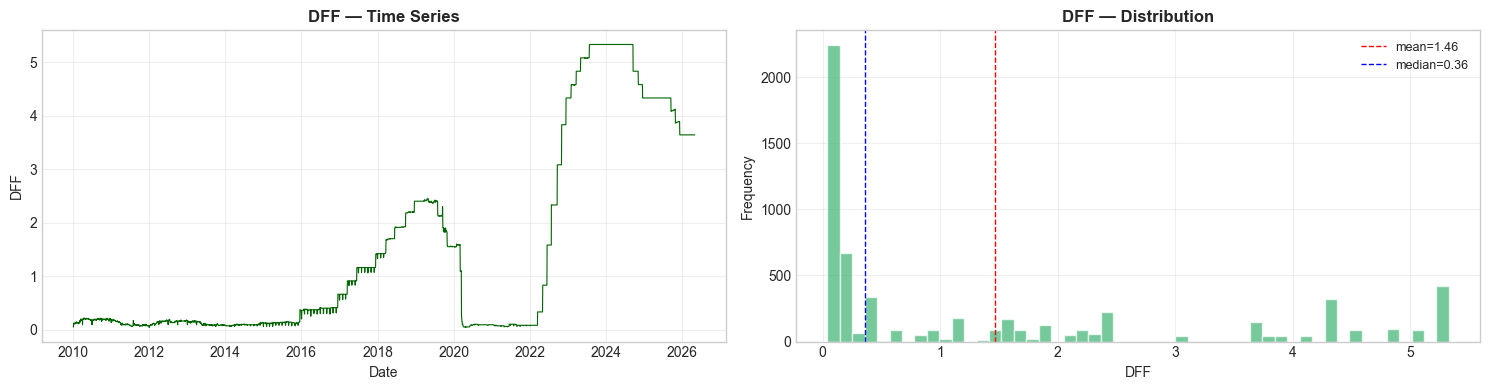


Saved: figures\data_inspection\fred\DFF.png

  DGS2  (daily | us_rates)
Description: US 2-Year Treasury Yield. Reflects short-term Fed rate expectations.
Shape: (4263, 2)
Date range: 2010-01-01 -> 2026-05-05
Missing: 176 (4.1%)

Statistics:
  mean:         1.6667
  std:          1.5556
  min:          0.0900
  max:          5.1900
  latest:       3.9300


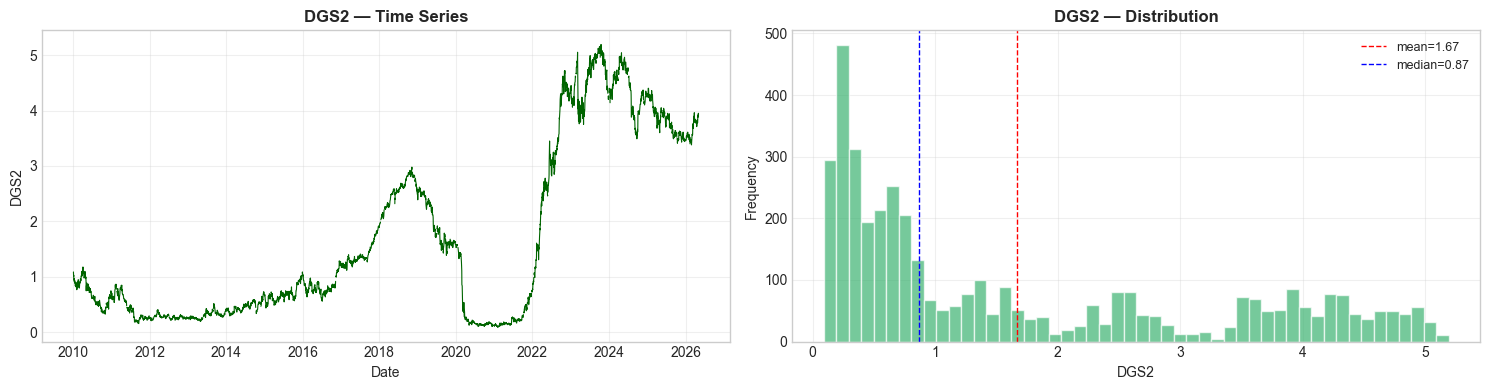


Saved: figures\data_inspection\fred\DGS2.png

  DGS10  (daily | us_rates)
Description: US 10-Year Treasury Yield. Long-term growth and inflation expectations.
Shape: (4263, 2)
Date range: 2010-01-01 -> 2026-05-05
Missing: 176 (4.1%)

Statistics:
  mean:         2.6451
  std:          1.0191
  min:          0.5200
  max:          4.9800
  latest:       4.4300


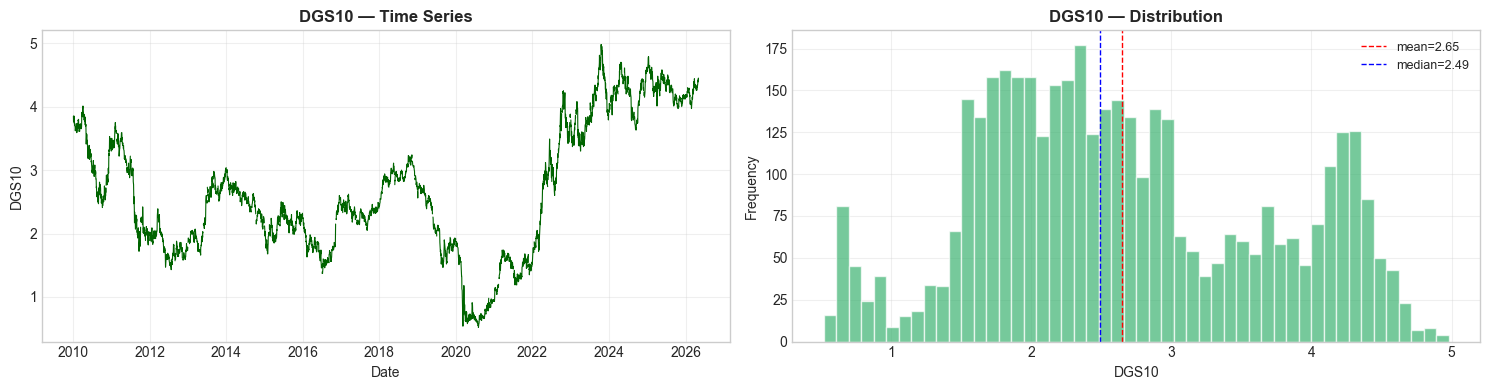


Saved: figures\data_inspection\fred\DGS10.png


In [3]:
fred_summaries = []

fred_summaries.append(inspect_fred_series(
    "DFF", "Effective Fed Funds Rate. Primary US monetary policy tool.",
    "daily", "us_rates"))

fred_summaries.append(inspect_fred_series(
    "DGS2", "US 2-Year Treasury Yield. Reflects short-term Fed rate expectations.",
    "daily", "us_rates"))

fred_summaries.append(inspect_fred_series(
    "DGS10", "US 10-Year Treasury Yield. Long-term growth and inflation expectations.",
    "daily", "us_rates"))

## 4. EU Interest Rates

ECB counterpart to US rates. The **US-EU rate differential** is a key FX driver.

- **ECBDFR:** ECB Deposit Facility Rate
- **IRLTLT01EZM156N:** Eurozone 10-Year Government Bond Yield


  ECBDFR  (daily | eu_rates)
Description: ECB Deposit Facility Rate. Primary EU monetary policy tool. Note: negative 2014-2022.
Shape: (5971, 2)
Date range: 2010-01-01 -> 2026-05-07
Missing: 0 (0.0%)

Statistics:
  mean:         0.4927
  std:          1.3613
  min:         -0.5000
  max:          4.0000
  latest:       2.0000


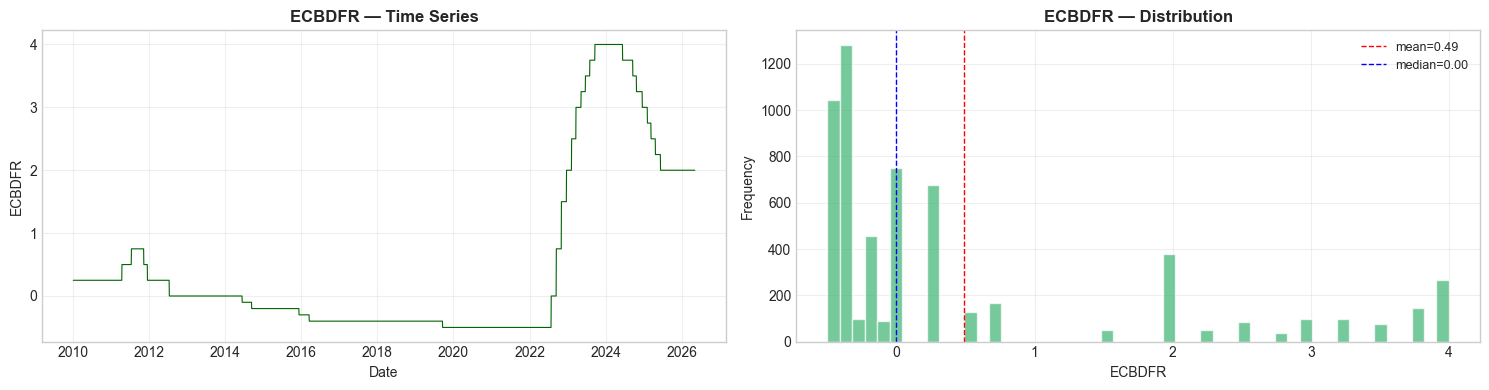


Saved: figures\data_inspection\fred\ECBDFR.png

  IRLTLT01EZM156N  (monthly | eu_rates)
Description: Eurozone 10-Year Government Bond Yield (composite).
Shape: (193, 2)
Date range: 2010-01-01 -> 2026-01-01
Missing: 0 (0.0%)

Statistics:
  mean:         2.0988
  std:          1.3203
  min:         -0.0919
  max:          4.6604
  latest:       3.2210


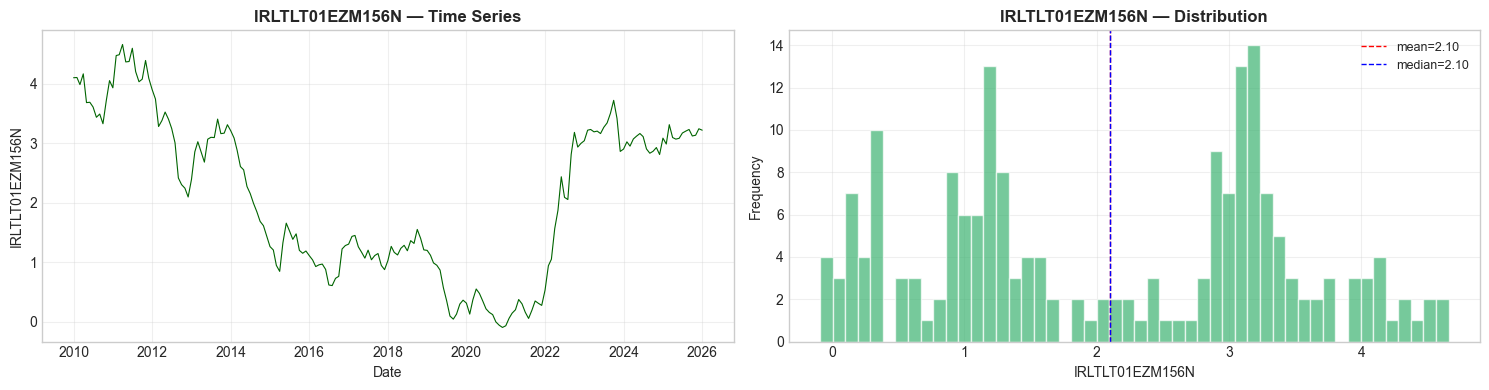


Saved: figures\data_inspection\fred\IRLTLT01EZM156N.png


In [4]:
fred_summaries.append(inspect_fred_series(
    "ECBDFR", "ECB Deposit Facility Rate. Primary EU monetary policy tool. Note: negative 2014-2022.",
    "daily", "eu_rates"))

fred_summaries.append(inspect_fred_series(
    "IRLTLT01EZM156N", "Eurozone 10-Year Government Bond Yield (composite).",
    "monthly", "eu_rates"))

## 5. Inflation

**Theory (PPP):** Higher inflation erodes currency value over the long term.

- **CPIAUCSL:** US Consumer Price Index
- **CP0000EZ19M086NEST:** Eurozone HICP
- **T10YIE:** US 10-Year Breakeven Inflation (market expectations)


  CPIAUCSL  (monthly | inflation)
Description: US Consumer Price Index (All Items). Driver of Fed policy.
Shape: (195, 2)
Date range: 2010-01-01 -> 2026-03-01
Missing: 1 (0.5%)

Statistics:
  mean:       259.1226
  std:         32.7689
  min:        217.1990
  max:        330.2930
  latest:     330.2930


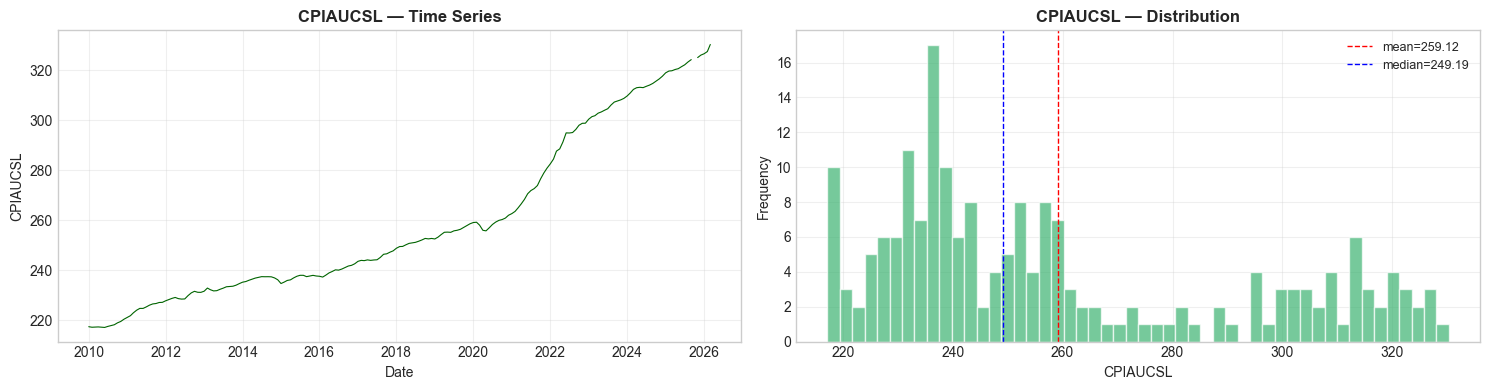


Saved: figures\data_inspection\fred\CPIAUCSL.png

  CP0000EZ19M086NEST  (monthly | inflation)
Description: Eurozone HICP (Harmonised Index of Consumer Prices). Driver of ECB policy.
Shape: (195, 2)
Date range: 2010-01-01 -> 2026-03-01
Missing: 0 (0.0%)

Statistics:
  mean:        83.0327
  std:          8.6334
  min:         71.1500
  max:        101.9800
  latest:     101.9800


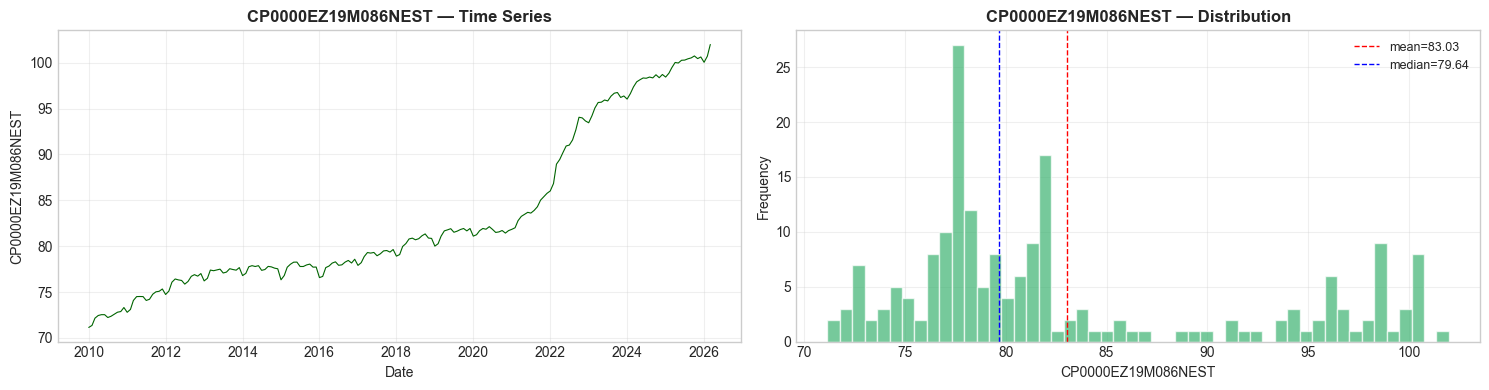


Saved: figures\data_inspection\fred\CP0000EZ19M086NEST.png

  T10YIE  (daily | inflation)
Description: US 10-Year Breakeven Inflation. Market's expected inflation.
Shape: (4264, 2)
Date range: 2010-01-01 -> 2026-05-06
Missing: 176 (4.1%)

Statistics:
  mean:         2.0774
  std:          0.3430
  min:          0.5000
  max:          3.0200
  latest:       2.4200


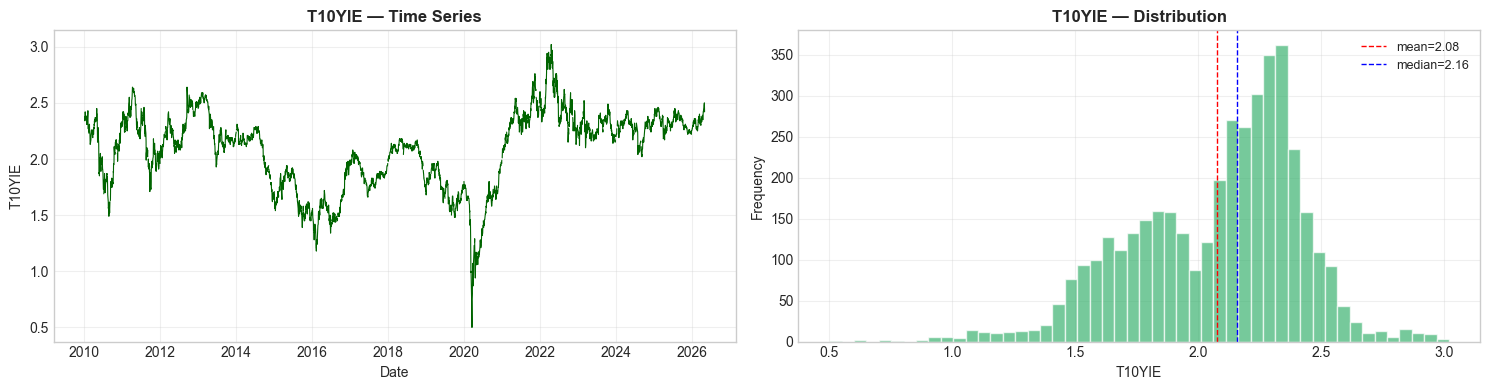


Saved: figures\data_inspection\fred\T10YIE.png


In [5]:
fred_summaries.append(inspect_fred_series(
    "CPIAUCSL", "US Consumer Price Index (All Items). Driver of Fed policy.",
    "monthly", "inflation"))

fred_summaries.append(inspect_fred_series(
    "CP0000EZ19M086NEST", "Eurozone HICP (Harmonised Index of Consumer Prices). Driver of ECB policy.",
    "monthly", "inflation"))

fred_summaries.append(inspect_fred_series(
    "T10YIE", "US 10-Year Breakeven Inflation. Market's expected inflation.",
    "daily", "inflation"))

## 6. Macro Health

Labor market indicators. Strong economy → potential rate hikes → currency strength.

- **UNRATE:** US Unemployment Rate
- **PAYEMS:** US Nonfarm Payrolls (high-impact monthly release)


  UNRATE  (monthly | macro)
Description: US Unemployment Rate. Reflects labor market health. Note: COVID spike 2020.
Shape: (195, 2)
Date range: 2010-01-01 -> 2026-03-01
Missing: 1 (0.5%)

Statistics:
  mean:         5.6876
  std:          2.1910
  min:          3.4000
  max:         14.8000
  latest:       4.3000


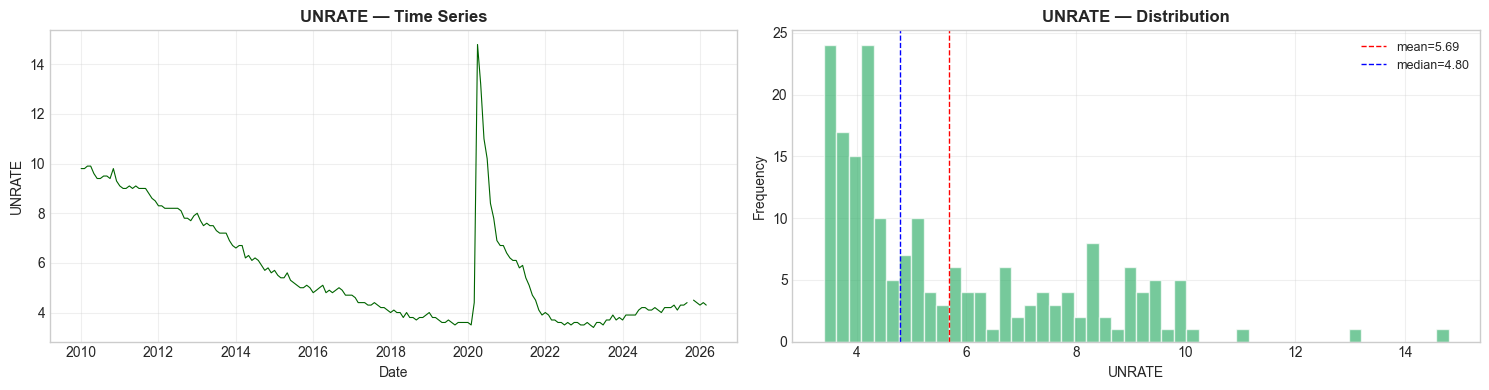


Saved: figures\data_inspection\fred\UNRATE.png

  PAYEMS  (monthly | macro)
Description: US Nonfarm Payrolls (thousands). Major monthly economic event.
Shape: (195, 2)
Date range: 2010-01-01 -> 2026-03-01
Missing: 0 (0.0%)

Statistics:
  mean:    145039.7385
  std:       8992.8813
  min:     129706.0000
  max:     158637.0000
  latest:  158637.0000


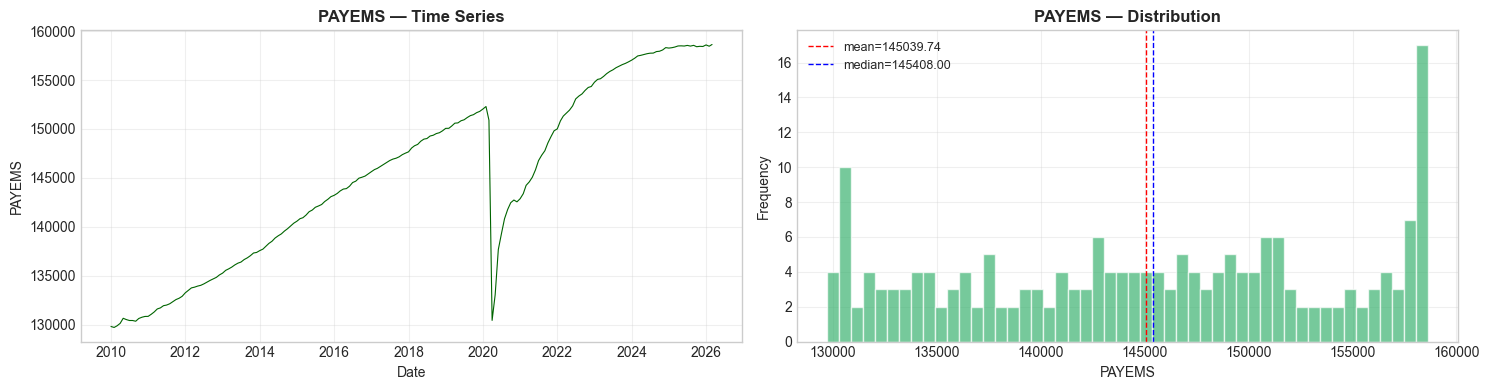


Saved: figures\data_inspection\fred\PAYEMS.png


In [6]:
fred_summaries.append(inspect_fred_series(
    "UNRATE", "US Unemployment Rate. Reflects labor market health. Note: COVID spike 2020.",
    "monthly", "macro"))

fred_summaries.append(inspect_fred_series(
    "PAYEMS", "US Nonfarm Payrolls (thousands). Major monthly economic event.",
    "monthly", "macro"))

## 7. Risk Sentiment & USD Strength

- **VIXCLS:** VIX "fear gauge" — high VIX → flight-to-USD → EUR/USD falls
- **DTWEXBGS:** Broad Trade-Weighted USD Index
- **DEXUSEU:** Official USD/EUR rate (for cross-validation)


  VIXCLS  (daily | risk_sentiment)
Description: VIX Volatility Index ('fear gauge'). High VIX -> risk-off -> flight-to-USD.
Shape: (4263, 2)
Date range: 2010-01-01 -> 2026-05-05
Missing: 125 (2.9%)

Statistics:
  mean:        18.4464
  std:          6.8199
  min:          9.1400
  max:         82.6900
  latest:      17.3800


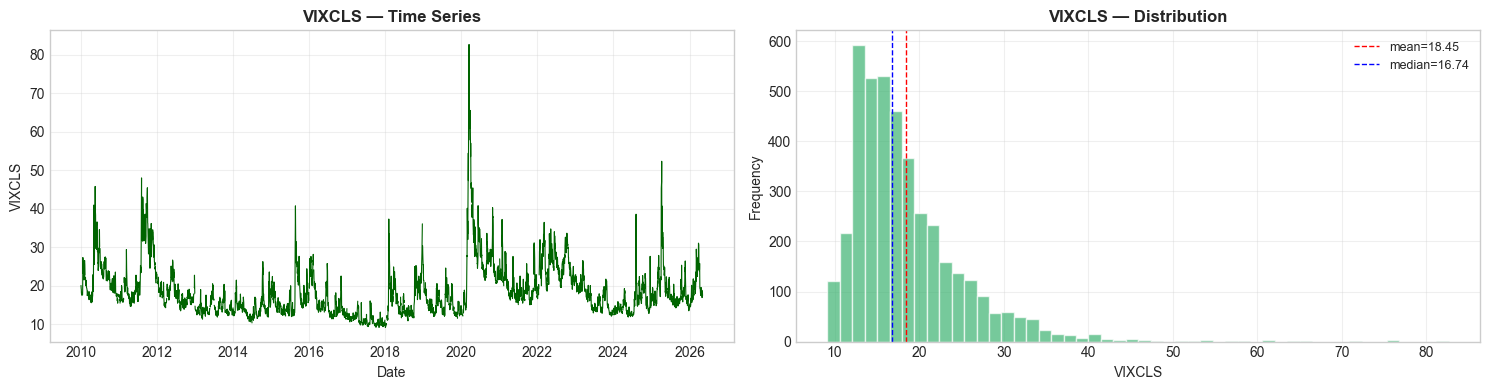


Saved: figures\data_inspection\fred\VIXCLS.png

  DTWEXBGS  (daily | usd_strength)
Description: Trade-Weighted USD Index (broad, 26 currencies).
Shape: (4261, 2)
Date range: 2010-01-01 -> 2026-05-01
Missing: 195 (4.6%)

Statistics:
  mean:       109.0509
  std:         12.0374
  min:         85.4692
  max:        130.0413
  latest:     118.3926


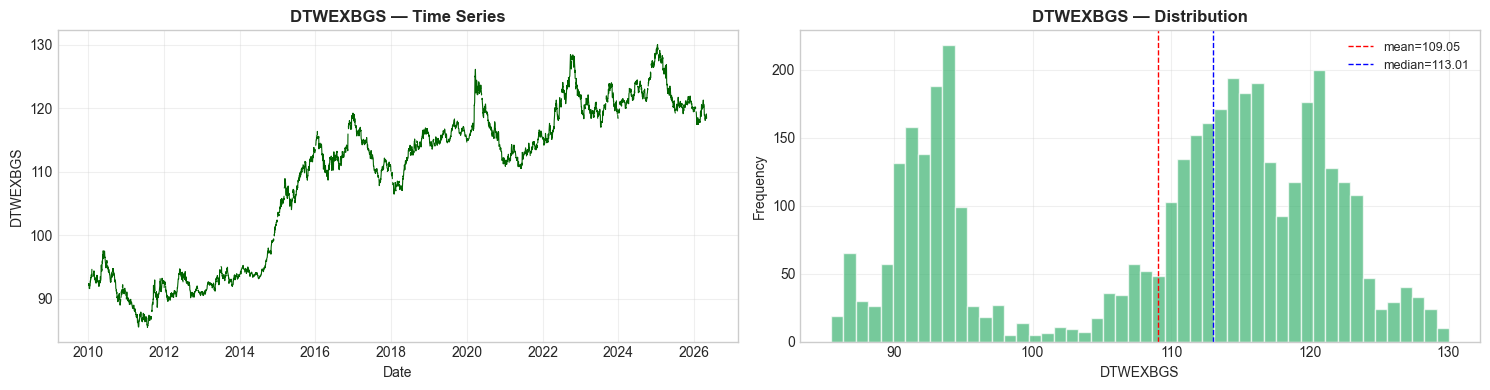


Saved: figures\data_inspection\fred\DTWEXBGS.png

  DEXUSEU  (daily | exchange_rate)
Description: Official USD/EUR exchange rate from Fed. Used for cross-validation.
Shape: (4261, 2)
Date range: 2010-01-01 -> 2026-05-01
Missing: 176 (4.1%)

Statistics:
  mean:         1.1862
  std:          0.1111
  min:          0.9616
  max:          1.4875
  latest:       1.1755


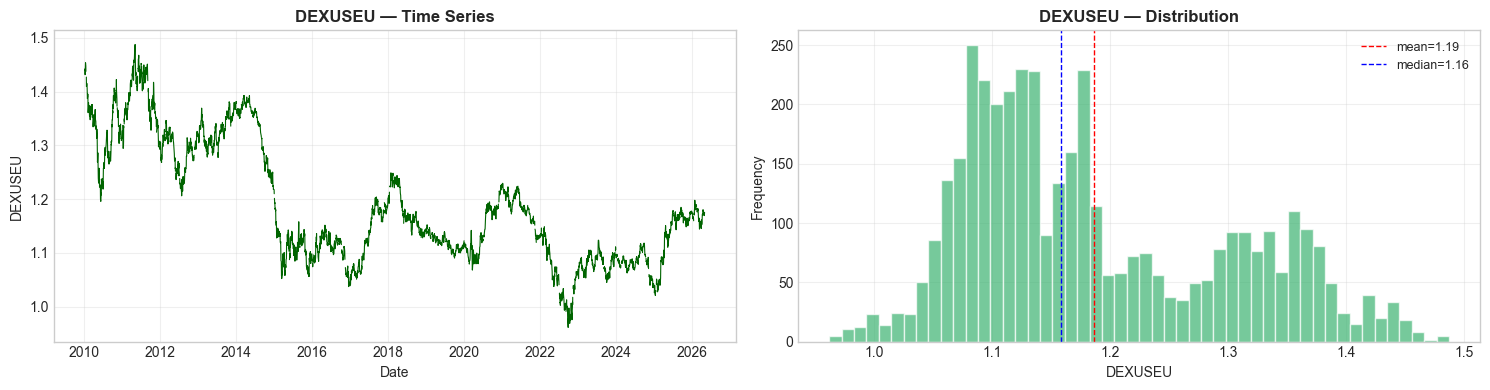


Saved: figures\data_inspection\fred\DEXUSEU.png


In [7]:
fred_summaries.append(inspect_fred_series(
    "VIXCLS", "VIX Volatility Index ('fear gauge'). High VIX -> risk-off -> flight-to-USD.",
    "daily", "risk_sentiment"))

fred_summaries.append(inspect_fred_series(
    "DTWEXBGS", "Trade-Weighted USD Index (broad, 26 currencies).",
    "daily", "usd_strength"))

fred_summaries.append(inspect_fred_series(
    "DEXUSEU", "Official USD/EUR exchange rate from Fed. Used for cross-validation.",
    "daily", "exchange_rate"))

## 8. Summary — All FRED Series

In [8]:
"""
Summary table of all 13 FRED series.
"""
summary_df = pd.DataFrame(fred_summaries)

print("FRED SERIES SUMMARY")
print("=" * 80)
print(summary_df.to_string(index=False))

print(f"\nCharts saved in {FIG_DIR.relative_to(PROJECT_ROOT)}:")
for png in sorted(FIG_DIR.glob("*.png")):
    print(f"  - {png.name}")

FRED SERIES SUMMARY
            series  rows  missing        mean       std         min         max
               DFF  5969        0      1.4628    1.8204      0.0400      5.3300
              DGS2  4263      176      1.6667    1.5556      0.0900      5.1900
             DGS10  4263      176      2.6451    1.0191      0.5200      4.9800
            ECBDFR  5971        0      0.4927    1.3613     -0.5000      4.0000
   IRLTLT01EZM156N   193        0      2.0988    1.3203     -0.0919      4.6604
          CPIAUCSL   195        1    259.1226   32.7689    217.1990    330.2930
CP0000EZ19M086NEST   195        0     83.0327    8.6334     71.1500    101.9800
            T10YIE  4264      176      2.0774    0.3430      0.5000      3.0200
            UNRATE   195        1      5.6876    2.1910      3.4000     14.8000
            PAYEMS   195        0 145039.7385 8992.8813 129706.0000 158637.0000
            VIXCLS  4263      125     18.4464    6.8199      9.1400     82.6900
          DTWEXBGS  

## Conclusion

### FRED Data Summary

 Inspected all **13 macroeconomic series**  
 Charts saved to `figures/data_inspection/fred/`

### Key Observations

- **US rates (DFF, DGS2, DGS10):** zero-rate era (2008-2022) → aggressive hiking (2022-2024) → ~5%
- **EU rates (ECBDFR):** negative rate era (-0.5%, 2014-2022) — unique to Europe
- **Inflation (CPI, HICP):** sharp rise post-COVID (2021-2023)
- **VIX:** spike to 80+ during COVID (March 2020)
- **DEXUSEU:** mirrors EUR/USD from yfinance (cross-validation)

### Frequency Note

Some series are **monthly** (CPI, HICP, UNRATE, PAYEMS, EU 10Y) — these will be forward-filled when merged into the daily master dataset.

### Next

`00c_inspect_ecb.ipynb` — inspect the 4 European Central Bank series.